## Projektübersicht


In [1]:
# =============================================================================
# Projekt: EMM – Modellierung eines gekoppelten Strom-Wärmesystems#
# Anwendungsfall: Mehrfamilienhaus (MFH)
#
# Ziel des Projekts ist der Vergleich der Auswirkungen unterschiedlicher
# Wärmeverteilungssysteme (Heizkörper vs. Fußbodenheizung) auf ein
# Wärmepumpen-basiertes Energiesystem unter Berücksichtigung verschiedener
# Sanierungsgrade des Gebäudes.
#
# Alle Parameter sind mit Quellenangaben der zugehörigen Excel zu entnehmen.
# =============================================================================

### Gebäude- und Systemannahmen

In [2]:
# =============================================================================
# Gebäude- und Systemannahmen
# =============================================================================
# Mehrfamilienhaus:
# - Beheizte Wohnfläche: 426 m² (siehe Excel-Datei mit Quellen)
# - Anzahl Wohneinheiten: 6
#
# Trinkwarmwasser:
# - Netto-Trinkwarmwasserbedarf: 16,5 kWh/(m²·a)
#
# Elektrisches System:
# - Installierbare PV-Leistung: 13 kWp (PV-Atlas)
#
# Wärmeversorgung:
# - Zentrale Luft-Wasser-Wärmepumpe
# - Geschichteter Wärmespeicher mit konstanten Temperaturschichten
# - Simulation in Stundenauflösung
# =============================================================================


### Sanierungsgrade

In [3]:
# =============================================================================
# Sanierungsgrade (Gebäudezustände)
# =============================================================================
# Zur Untersuchung des Einflusses des Gebäudezustands werden drei
# Sanierungsgrade betrachtet, die sich ausschließlich im spezifischen
# Heizwärmebedarf unterscheiden:

# Fall 1: Ist-Zustand (unsaniert)
# - Netto-Heizwärmebedarf: 168,6 kWh/(m²·a)

# Fall 2: Konventionell saniert (Teilsanierung)
# - Netto-Heizwärmebedarf: 82,5 kWh/(m²·a)

# Fall 3: Zukunftsführend saniert (Vollsanierung)
# - Netto-Heizwärmebedarf: 25,0 kWh/(m²·a)
# =============================================================================

### Heizkörper vs. Fußbodenheizung modelieren

In [4]:
# =============================================================================
# Wärmeverteilungssysteme: Heizkörper (HK) vs. Fußbodenheizung (FBH)
# =============================================================================
# Für jeden Sanierungsgrad wird das Energiesystem jeweils mit zwei
# unterschiedlichen Wärmeverteilungssystemen simuliert:

# Heizkörper (HK):
# - Höhere Vorlauftemperaturen (45-55°C)
# - Typisch für Bestandsgebäude
# - Geringere Temperaturspreizung im Wärmespeicher
#
# Fußbodenheizung (FBH):
# - Niedrigere Vorlauftemperaturen (30-35°C)
# - Größere Temperaturspreizung im Wärmespeicher
# - Höhere Effizienz der Wärmepumpe durch niedrigere Temperaturniveaus
#
# Der Wechsel zwischen HK und FBH erfolgt im Modell ausschließlich über:
# - die dafür jeweils geforderte Vorlauftemperatur (T_vorlauf, T_flow)
# - und damit auch die Rücklauftemperatur des Wärmespeichers (T_return)
# =============================================================================

## Code

### Imports

In [5]:
import pypsaheat as ph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
from pathlib import Path
import sys
from matplotlib import cm

C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


### Wärmelastgänge - PV-Erzeugung - Außentemperatur - laden

In [6]:
# ------------------------------------------------------------
# Wärmelasten der Sanierungsgrade laden
# ------------------------------------------------------------

# Fall auswählen (nur EINEN aktiv lassen)
# Fall 1: Ist-ZST-Last
lastgang_file = "../Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_Ist_ZST.csv"

# Fall 2: Konventionelle Last
# lastgang_file = "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_konventionell.csv"

# Fall 3: Zukunftsführende Last
# lastgang_file = "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_zukunftsfuehrend.csv"

# Version automatisch aus Dateiname ableiten lassen
lf = lastgang_file.lower()
if "ist_zst" in lf:
    lastgang_version = "Ist_ZST"
elif "konventionell" in lf:
    lastgang_version = "konventionell"
elif "zukunft" in lf:
    lastgang_version = "zukunftsfuehrend"
else:
    lastgang_version = "unknown"

df = pd.read_csv(lastgang_file, sep=",", decimal=".")

# --- Zeitspalte finden ---
time_col = next((c for c in df.columns if "Zeit" in c), None)
if time_col is None:
    raise ValueError(f"Keine Zeitspalte gefunden. Spalten: {df.columns.tolist()}")

# --- Zeitspalte in datetime umwandeln ---
df["Zeit"] = pd.to_datetime(
    "2019-" + df[time_col].astype(str),
    format="%Y-%d-%m %H:%M",
    errors="coerce"
)

# --- Index setzen ---
df = df.set_index("Zeit").sort_index()

print("Index-Typ:", type(df.index), "Min/Max:", df.index.min(), df.index.max())



Index-Typ: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> Min/Max: 2019-01-01 00:00:00 2019-12-31 23:00:00


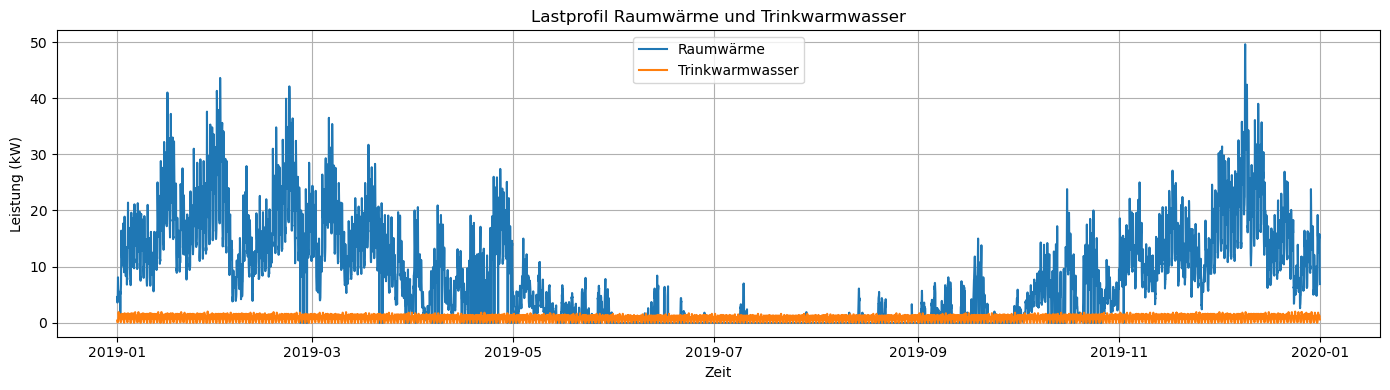

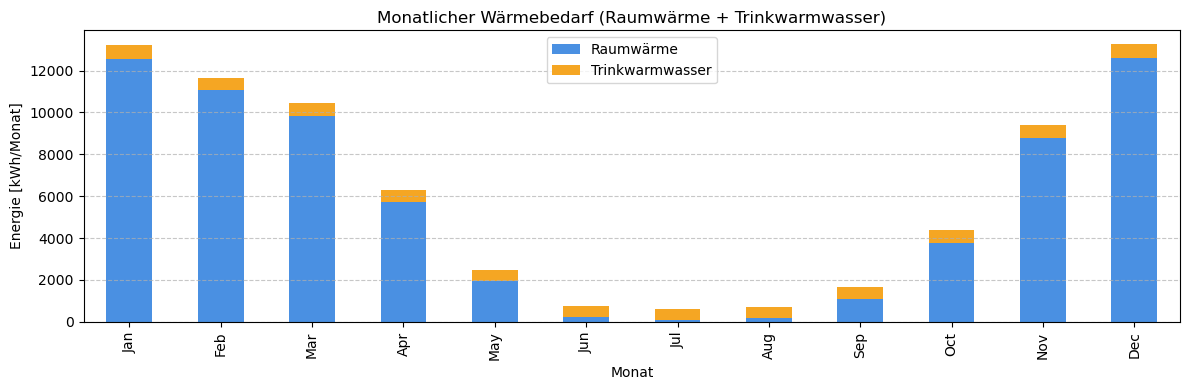

In [7]:
# ------------------------------------------------------------
# Plot der Lasten erstellen
# ------------------------------------------------------------

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Raumwaerme_(kW)"], label="Raumwärme")
plt.plot(df.index, df["Trinkwarmwasser_(kW)"], label="Trinkwarmwasser")

plt.legend()
plt.title("Lastprofil Raumwärme und Trinkwarmwasser")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Monats-Balkendiagramm: Raumwärme + Trinkwarmwasser
# ------------------------------------------------------------

# Monatsenergie berechnen (kWh/Monat bei 1h-Zeitschritt)
monthly_heat = df.resample("ME")[[
    "Raumwaerme_(kW)",
    "Trinkwarmwasser_(kW)"
]].sum()

# Monatsnamen hübsch
monthly_heat.index = monthly_heat.index.strftime("%b")

# Plot
ax = monthly_heat.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4),
    color=["#4A90E2", "#F5A623"]  # Blau = Raumwärme, Orange = TWW
)

ax.set_title("Monatlicher Wärmebedarf (Raumwärme + Trinkwarmwasser)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie [kWh/Monat]")
ax.legend(["Raumwärme", "Trinkwarmwasser"])
ax.grid(axis="y", alpha=0.7, linestyle="--")

plt.tight_layout()
plt.show()

In [8]:
# ------------------------------------------------------------
# PV Erzeugungsprofil laden
# ------------------------------------------------------------
# Annahmen: Dataset MERRA-2 (global), 2019, capacity 1kW, system loss 0.1 , Tilt 35°, Azimuth 180°, included raw data
pv = pd.read_csv(
    "../Input_Data/ninja_pv_50.9384_6.9600_corrected.csv",
    skiprows=3,
    parse_dates=["local_time"],
)

pv = pv.set_index("local_time")

pv = pv.rename(columns={
    "electricity": "pv_electricity",
    "irradiance_direct": "direct",
    "irradiance_diffuse": "diffuse",
    "temperature": "temp"
})

pv.head(100)

,time,pv_electricity,direct,diffuse,temp
local_time,,,,,
2019-01-01 01:00:00,2019-01-01 00:00,0.0,0.0,0.0,6.294
2019-01-01 02:00:00,2019-01-01 01:00,0.0,0.0,0.0,6.003
2019-01-01 03:00:00,2019-01-01 02:00,0.0,0.0,0.0,5.710
2019-01-01 04:00:00,2019-01-01 03:00,0.0,0.0,0.0,5.540
2019-01-01 05:00:00,2019-01-01 04:00,0.0,0.0,0.0,5.458
...,...,...,...,...,...
2019-01-05 00:00:00,2019-01-04 23:00,0.0,0.0,0.0,2.187
2019-01-05 01:00:00,2019-01-05 00:00,0.0,0.0,0.0,2.378
2019-01-05 02:00:00,2019-01-05 01:00,0.0,0.0,0.0,2.531


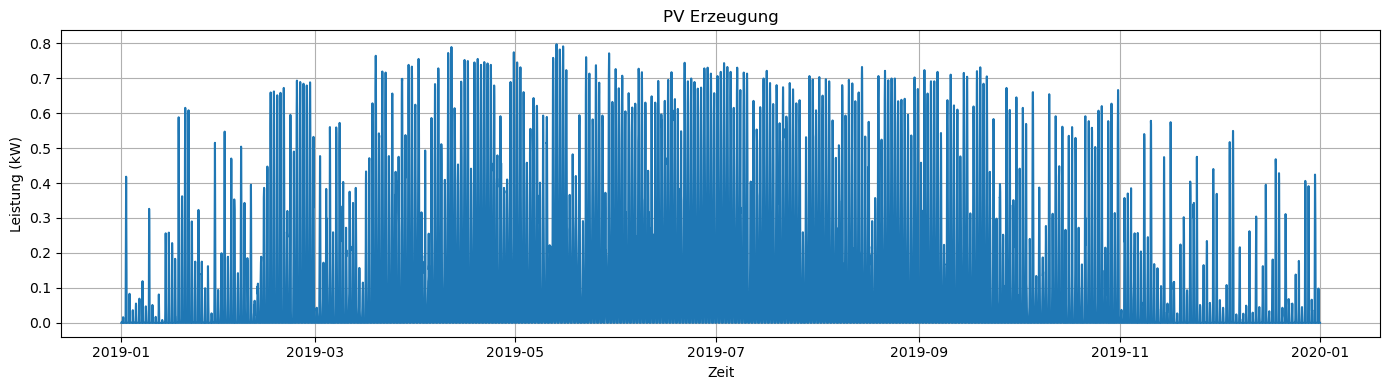

In [9]:
# ------------------------------------------------------------
# Erzeugungsprofil PV plotten
# ------------------------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(pv.index, pv["pv_electricity"], label="PV (kW)")
plt.title("PV Erzeugung")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# ------------------------------------------------------------
# Außentemperaturdaten laden
# ------------------------------------------------------------

weather = pd.read_csv(
    "../Input_Data/ninja_weather_50.9384_6.9600_2019_uncorrected.csv",
    skiprows=3,
    parse_dates=["local_time"]
)

# Index setzen
weather = weather.set_index("local_time")

# Umbenennen: t2m → T_outdoor
weather = weather.rename(columns={"t2m": "T_outdoor"})

# Nur Temperatur extrahieren
T_outdoor = weather["T_outdoor"]

T_outdoor.head()

local_time
2019-01-01 01:00:00    6.294
2019-01-01 02:00:00    6.003
2019-01-01 03:00:00    5.710
2019-01-01 04:00:00    5.540
2019-01-01 05:00:00    5.458
Name: T_outdoor, dtype: float64

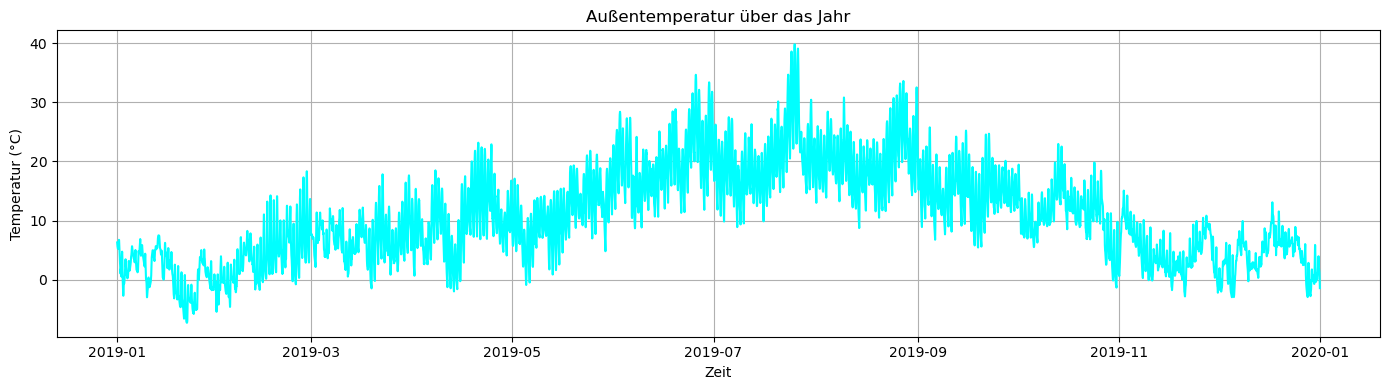

In [11]:
# -------------------------------------------
# Außentemperatur plotten
# -------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(weather.index, weather["T_outdoor"], label="Außentemperatur (°C)", color="cyan")

plt.title("Außentemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Vorlauftemperatur & Rücklauf (HK/FBH)

In [12]:
# ------------------------------------------------------------
# Heizkörper vs. Fußbodenheizung über Heizkurve (T_voralauf, T_flow)
# ------------------------------------------------------------

# Flag: True = Heizkörper, False = Fußbodenheizung
use_radiators = True

# HK T_vorlauf = 45 - 55 °C; FBH T_Vorlauf = 30 - 35 °C
T_vorlauf = 51.0 if use_radiators else 33.0         # 51 °C bei 0°C ; bzw 33 bei 0°C (nach Quelle - 30°C bei -10°C bzw. - 55° bei -10°C)
T_gradient = 6/15 if use_radiators else 3/15        # wie stark die Vorlauftemperatur mit der Außentemp. steigt/fällt

# Heizkurve berechnen (PyPSA_heat-Funktion)
T_flow = ph.physics.flow_temperature(T_vorlauf, T_gradient, T_outdoor)

heating_cutoff = 15.0                          # °C Außentemperatur, ab der nicht mehr geheizt wird
heat_on = T_outdoor <= heating_cutoff
T_flow_min = 45 if use_radiators else 30       # Mindestvorlauftemperatur
T_flow = T_flow.clip(lower=T_flow_min)
T_flow = T_flow.where(heat_on, T_flow_min)

#Rücklauftemperatur vorgeben
delta_T = 10.0 if use_radiators else 5.0       # FBH hat geringere Rücklauftemperatur
store_T_return  = T_flow_min - delta_T         # °C Rücklauftemperatur 35 HK und 25 FBH

store_T_return

35.0

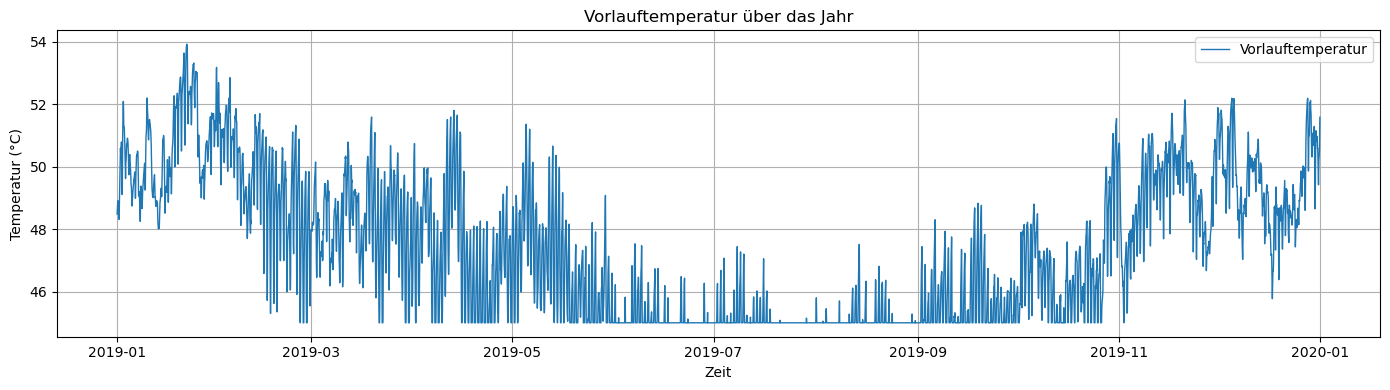

In [13]:
plt.figure(figsize=(14,4))
plt.plot(weather.index, T_flow, label="Vorlauftemperatur", linewidth=1)

plt.title("Vorlauftemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Komponentenparameter & Kosten

In [14]:
# --------------------------------
# Parametrisierung der Komponenten
# --------------------------------

#Strom Daten
grid_power      =   87        # kW Hausanschluss Leistung
grid_cost       =   0.372     # €/kWh Kosten für Netzstrombezug

interest_rate = 0.02

# PV - Daten
pv_invest       =   731       # €/kWp (einmalig)
pv_lifetime     =   20        # Jahre
PV_power        =   13        # kWp
feed_in_tariff  =   -0.0778   # €/kWh
pv_annuity = pv_invest * ((1+interest_rate)**pv_lifetime) * interest_rate / ((1+interest_rate)**pv_lifetime - 1)


#Batterie Daten
battery_invest           = 500     # €/kWh
battery_lifetime         = 20      # Jahre
battery_annuity = battery_invest * ((1+interest_rate)**battery_lifetime) * interest_rate / ((1+interest_rate)**battery_lifetime - 1)


#Wärmespeicher Daten
store_height    =   2.15      #m
store_base      =   0.708     #  m²
# Volumen = store_base * store_height = 1.52 m³
store_u_wall    =   0.36      # W/(m²*K)
store_T_layers  =   [60, 55, 50, 45, 40] if use_radiators else [60, 55, 50, 45, 40, 35, 30]  #°C Temperaturschichten;
store_invest    =   1690      # €/kWh
store_lifetime  =   20        # Jahre
store_annuity   = store_invest * ((1+interest_rate)**store_lifetime) * interest_rate / ((1+interest_rate)**store_lifetime - 1)

# Heizstab
HE_power        =   9       # Heizstab-Nennleistung (kW)

# Wärmepumpe
HP_power        =    30     # WP-Nennleistung (kW_th)


### Energiesystem

In [15]:
# ------------------------------------------------------------
# Allgemeine Einstellungen des Networks
# ------------------------------------------------------------

snapshots = df.index   # DatetimeIndex aus deinem Lastgang (2019-01-01 ... 2019-12-31 23:00)

n = ph.HeatNetwork()
n.set_snapshots(snapshots)


# ------------------------------------------------------------
# Modellierung des Energiesystems
# ------------------------------------------------------------
# Busse
n.add("Bus", "electricity_grid")
n.add("Bus", "electricity_infeed")

# Grid import
n.add("Generator", "grid_import",
      bus="electricity_grid",
      p_nom=grid_power,
      marginal_cost=grid_cost)

# PV generation
n.add("Generator", "pv_generation",
      bus="electricity_infeed",
      p_nom=PV_power,
      p_max_pu=pv["pv_electricity"].values,
      capital_cost=pv_annuity)

# Strom einspeisen - export Generator
n.add("Generator", "pv_infeed",
      bus="electricity_infeed",
      p_nom=PV_power,                   # begrenzt die max. Exportleistung
      marginal_cost=feed_in_tariff,
      sign=-1)

# Link PV -> Hausnetz
n.add("Link", "electricity_link",
      bus0="electricity_infeed",
      bus1="electricity_grid",
      p_nom=PV_power,
      efficiency=1.0)

# Batterie (auf Hausnetz)
n.add("StorageUnit", "store_el",
      bus="electricity_grid",
      e_nom_extendable=True,
      e_cyclic=True,
      standing_loss=0.01,
      capital_cost=battery_annuity,
      efficiency_store=0.95,
      efficiency_dispatch=0.95)

# Wärmespeicher
n.add("HeatStore", "hs_mfh",
      constant="temperature",
      height=store_height,
      base=store_base,
      T_layer=store_T_layers,
      T_return=store_T_return,
      V_initial=[0]*len(store_T_layers),
      cyclic=True,
      T_amb=18.0,
      U_wall=store_u_wall)

# Wärmepumpe (FIX p_nom)
n.add("HeatPump", "hp_mfh",
      bus0="electricity_grid",
      heat_store="hs_mfh",
      p_nom=HP_power,
      T_source=T_outdoor.values,
      T_max=65,
      heat_source="air")

# Heizstab
n.add("HeatingElement", "backup_heater",
      bus0="electricity_grid",
      heat_store="hs_mfh",
      p_nom=HE_power,
      efficiency=0.95)

# Elektrische Haushaltslast
n.add("Load", "el_demand",
      bus="electricity_grid",
      p_set=df["Strom_gesamt_(kW)"].values)

# HeatLoads
n.add("HeatLoad", "Raumwaerme",
      heat_store="hs_mfh",
      p_set=df["Raumwaerme_(kW)"].values,
      T_demand=T_flow.values)

n.add("HeatLoad", "dhw",
      heat_store="hs_mfh",
      p_set=df["Trinkwarmwasser_(kW)"].values,
      T_demand=60.0)

# ------------------------------------------------------------------
# System lösen
n.optimize(solver_name="gurobi")
# ------------------------------------------------------------------


C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dty

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2694931


INFO:gurobipy:Set parameter LicenseID to value 2694931


...

Solved in 85370 iterations and 1.16 seconds (1.52 work units)


INFO:gurobipy:Solved in 85370 iterations and 1.16 seconds (1.52 work units)


Optimal objective  7.992800616e+03


INFO:gurobipy:Optimal objective  7.992800616e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 201480 primals, 411720 duals
Objective: 7.99e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, HeatStore-hs_mfh-fix-volume-upper, HeatStore-hs_mfh-fix-volume-lower, HeatStore-hs_mfh-layer_balance, HeatStore-hs_mfh-internal-lower, HeatingElement-backup_heater-fix-p-lower, HeatingElement-backup_heater-fix-p-upper, HeatPump-hp_mfh-fix-p-lower, HeatPump-hp_mfh-fix-p-upper, HeatPump-hp_mfh-fix-p-layer-lower, HeatPump-hp_mfh-fix-p-layer-upper were not assigned to the

PyPSA Heat Network
Components:
 - Bus: 2
 - Generator: 3
 - Link: 1
 - Load: 1
 - StorageUnit: 1
 - HeatLoad: 2
 - HeatPump: 1
 - HeatStore: 1
 - HeatingElement: 1
Snapshots: 8760

### Energiesystem: Ergebnisse & Kennzahlen

#### Wärmespeicher

C:\Users\sarah\AppData\Local\Temp\ipykernel_42552\2363582702.py:40: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.




================ Wärmespeicher Summary ================
HS: hs_mfh | Vtot=1.522 m³ (H=2.15 m, A=0.708 m²)
T_layer: [40, 45, 50, 55, 60] °C | T_return: 35 °C

        Schicht  Volumen über Jahr [m³·h] Anteil an Jahresnutzung [%] Aktive Stunden [h/a] (V > 0) Volumen über Jahr [m³]
T_return (35°C)               7106.081945                       53,29                      6719,00                 7106,1
           40°C                  7.184983                        0,05                      2521,00                    7,2
           45°C                  7.793358                        0,06                      3274,00                    7,8
           50°C               1496.247249                       11,22                      4492,00                 1496,2
           55°C               1391.302579                       10,43                      5254,00                 1391,3
           60°C               3325.861886                       24,94                      6911,00           

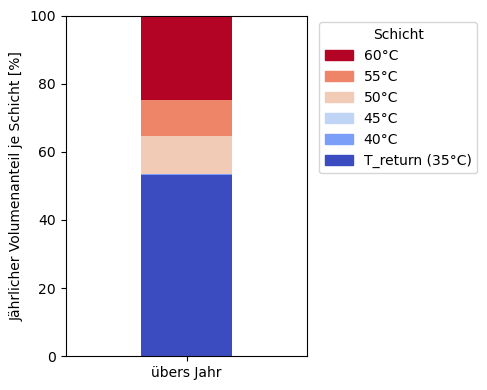

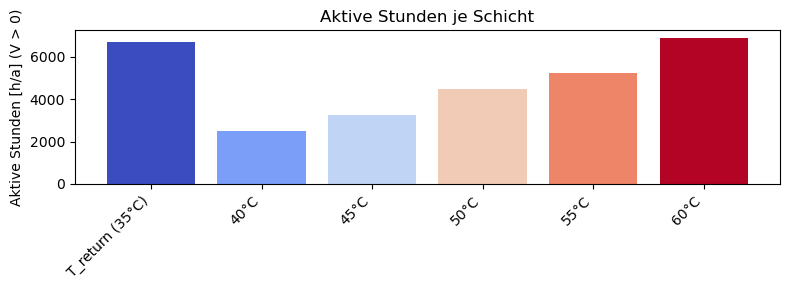

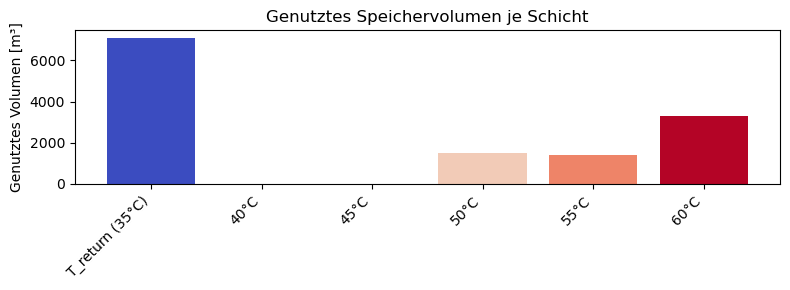

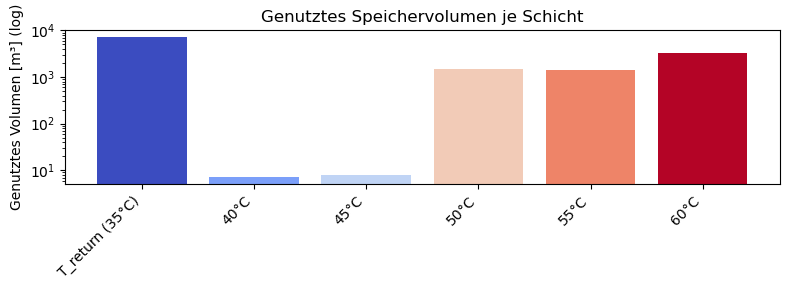

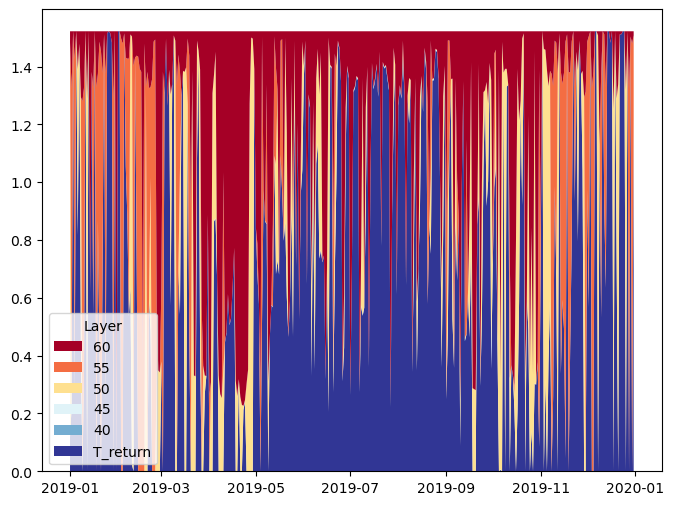

In [16]:
hs = "hs_mfh"

# ---------- Parameter ----------
H = float(n.heat_stores.loc[hs, "height"])
A = float(n.heat_stores.loc[hs, "base"])
Vtot = H * A                                                     # Gesamt Speichervolumen

T_layers = np.array(n.heat_stores.loc[hs, "T_layer"], float)
T_return = float(n.heat_stores.loc[hs, "T_return"])

V_layers = n.heat_stores_t["V_layer"][hs]
V_return_ts = (Vtot - V_layers.sum(axis=1)).clip(lower=0.0)

# kalt -> heiß
order = np.argsort(T_layers)
T_sorted = T_layers[order]
V_sorted = V_layers.iloc[:, order]

# ---------- Kennzahlen ----------

year_V_layers = V_sorted.sum(axis=0).values      # m³·h
year_V_return = V_return_ts.sum()                # m³·h

year_total = year_V_layers.sum() + year_V_return

share_layers_pct = year_V_layers / year_total * 100
share_return_pct = year_V_return / year_total * 100

active_layers_h = (V_sorted > 0).sum(axis=0)              # Anzahl aktiver Schichten; z.B.: "Schicht X °C war 4200 Stunden aktiv"
active_return_h = int((V_return_ts > 0).sum())              # Stunden des Rücklaufs im Jahr aktiv; aktiv = V>0 !

labels = [f"T_return ({T_return:.0f}°C)"] + [f"{t:.0f}°C" for t in T_sorted]

year_m3h = np.r_[year_V_return, year_V_layers]
year_V = np.r_[year_V_return, year_V_layers]
share_pct = np.r_[share_return_pct, share_layers_pct]
active_h = np.r_[active_return_h, active_layers_h]

# ---------- Farben kalt->heiß ----------
cmap = cm.get_cmap("coolwarm")
temps_for_colors = np.r_[T_return, T_sorted]
norm = (temps_for_colors - temps_for_colors.min()) / (temps_for_colors.max() - temps_for_colors.min() + 1e-12)
colors = cmap(norm)

# ---------- Tabelle mit Daten  ----------
df = pd.DataFrame({
    "Schicht": labels,
    "Volumen über Jahr [m³·h]": year_m3h,
    "Anteil an Jahresnutzung [%]": share_pct,
    "Aktive Stunden [h/a] (V > 0)": active_h
})

df_print = df.copy()
df_print["Volumen über Jahr [m³]"] = df_print["Volumen über Jahr [m³·h]"].map(lambda x: f"{x:.1f}".replace(".", ","))
df_print["Anteil an Jahresnutzung [%]"] = df_print["Anteil an Jahresnutzung [%]"].map(lambda x: f"{x:.2f}".replace(".", ","))
df_print["Aktive Stunden [h/a] (V > 0)"] = df_print["Aktive Stunden [h/a] (V > 0)"].map(lambda x: f"{x:.2f}".replace(".", ","))


print("\n================ Wärmespeicher Summary ================")
print(f"HS: {hs} | Vtot={Vtot:.3f} m³ (H={H:.2f} m, A={A:.3f} m²)")
print(f"T_layer: {list(map(int, T_sorted))} °C | T_return: {T_return:.0f} °C")
print("======================================================\n")
print(df_print.to_string(index=False))

print(f"\nSanity: Summe Anteile = {df['Anteil an Jahresnutzung [%]'].sum():.2f}%")


# ---------- Plot 1: Jahresauswertung gestapelt (Volumenanteile) ----------
fig, ax = plt.subplots(figsize=(5,4))
bottom = 0.0
for lab, val, col in zip(labels, share_pct, colors):
    ax.bar(0, val, bottom=bottom, color=col, width=0.6, edgecolor="none")
    bottom += val

ax.set_xlim(-0.8, 0.8)
ax.set_xticks([0])
ax.set_xticklabels(["übers Jahr"])
ax.set_ylim(0, 100)
ax.set_ylabel("Jährlicher Volumenanteil je Schicht [%]")
# ax.set_title("Jahresauswertung: Nutzung der Schichten")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in colors[::-1]]
ax.legend(handles, labels[::-1], title="Schicht", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------- Plot 2: Aktivität je Schicht ----------
plt.figure(figsize=(8,3))
plt.bar(labels, active_h, color=colors, edgecolor="none")
plt.ylabel("Aktive Stunden [h/a] (V > 0)")
plt.title("Aktive Stunden je Schicht")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot 2.1: genutztes Volumen je Schicht im jahr ----------
plt.figure(figsize=(8,3))
plt.bar(labels, year_V, color=colors, edgecolor="none")
plt.ylabel("Genutztes Volumen [m³]")
plt.title("Genutztes Speichervolumen je Schicht")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot: genutztes Volumen je Schicht (log y) ----------
eps = 1e-3  # kleines Volumen für log-Darstellung
year_V_plot = np.maximum(year_V, eps)

plt.figure(figsize=(8,3))
plt.bar(labels, year_V_plot, color=colors, edgecolor="none")
plt.yscale("log")
plt.ylabel("Genutztes Volumen [m³] (log)")
plt.title("Genutztes Speichervolumen je Schicht")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ---------- Plot 3: pypsaheat Zeitplot (dein Standard) ----------
sns_to_plot = n.snapshots[::24]  # 1 Punkt pro Tag
ph.plot.plot_stratified_heat_store(n, hs=hs, sns=sns_to_plot)



#### Wärmepumpe – Betrieb, COP & JAZ


Wärmepumpe – Auswertung (hp_mfh)


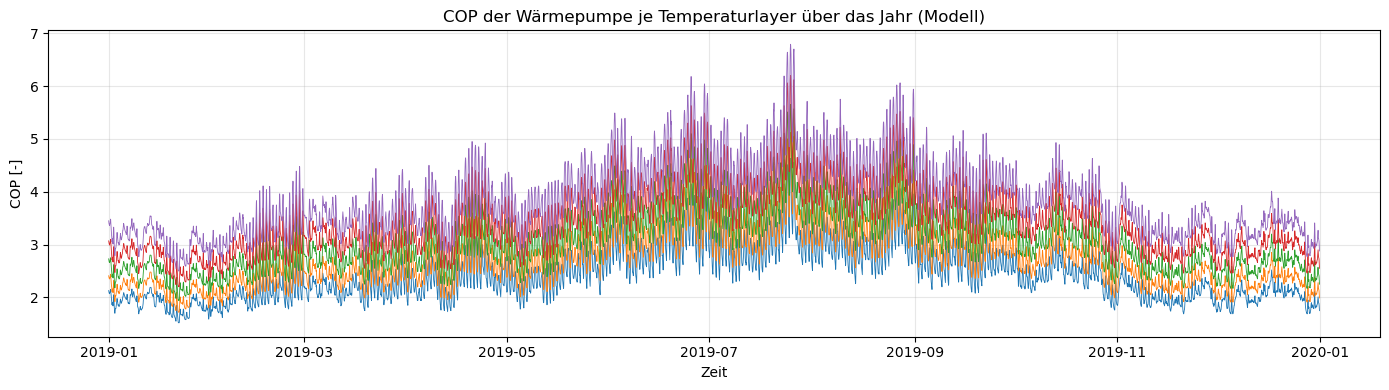


--- Auslegung ---
Thermische Nennleistung p_nom: 30.00 kW_th

--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---
COP Mittelwert: 2.84
COP Median:     2.76
COP Minimum:    1.72
COP Maximum:    6.42

--- Jahresenergien ---
WP Stromverbrauch: 29761.98 kWh_el/a
WP Wärmeerzeugung: 75251.54 kWh_th/a

--- JAZ ---
JAZ_HP (Q_hp / E_hp): 2.528


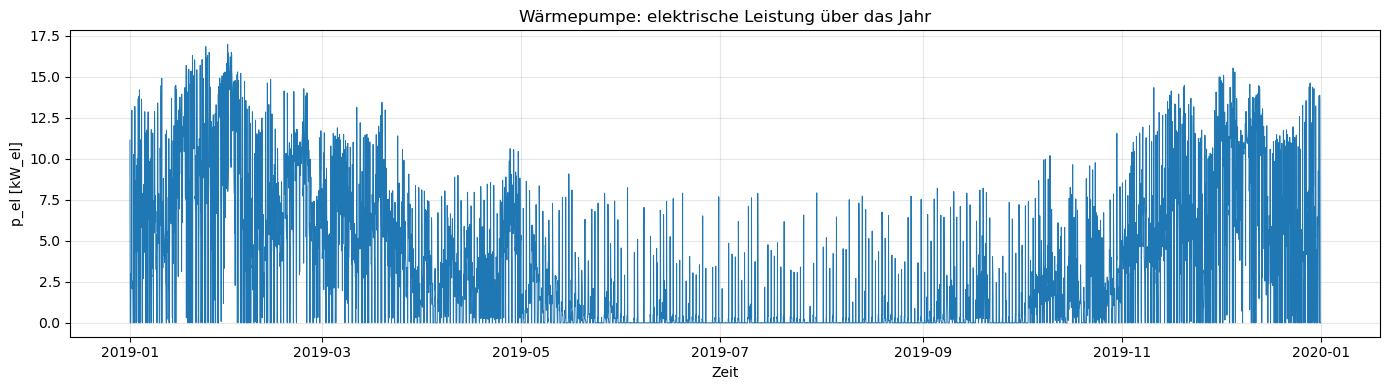

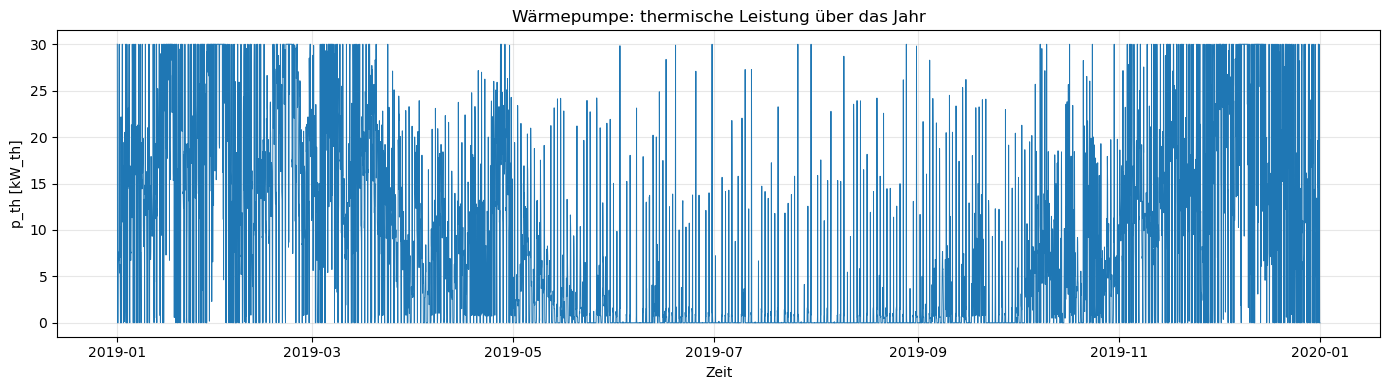

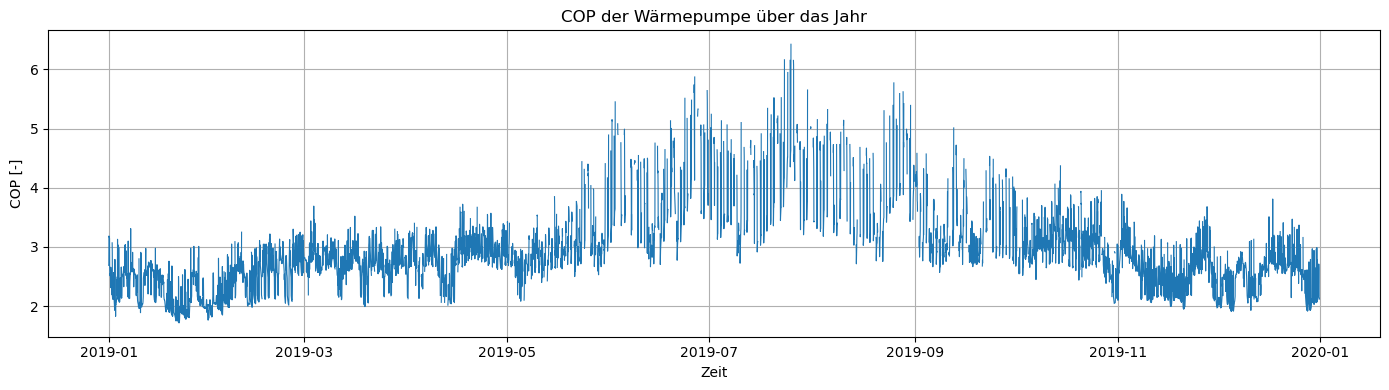

Index(['bus0', 'heat_store', 'type', 'carrier', 'p_nom', 'm_nom', 'T_source',
       'T_nom', 'T_max', 'COP_model', 'heat_source'],
      dtype='object', name='attribute')
attribute
bus0           electricity_grid
heat_store               hs_mfh
type                           
carrier                        
p_nom                      30.0
m_nom                       0.0
T_source                    0.0
T_nom                      60.0
T_max                      65.0
COP_model                   0.0
heat_source                 air
Name: hp_mfh, dtype: object


In [17]:
# ============================================================
# Wärmepumpe (hp_mfh): Kennzahlen, COP-Verlauf, JAZ
# ============================================================

hp_name = "hp_mfh"
hp_df = n.df("HeatPump")        # Tabelle Parameter HP
hp_t  = n.pnl("HeatPump")       # Zeitreihen-Container pro Std. für HP (p_heat, p_elec, COP)

print("\n====================================")
print(f"Wärmepumpe – Auswertung ({hp_name})")
print("====================================")

# --- Modellergebnisse der WP  ---
cop_model  = hp_t["COP"][hp_name]         # kommt aus unserem Model und kann mehere     Temperaturschichten bedienen
p_el_model = hp_t["p_elec"][hp_name]      # p_el_model = elektrische Leistung der WP
p_th_model = hp_t["p_heat"][hp_name]      # p_th_model = thermische Leistung der WP

# ============================================================
# Extra Plot: COP je Temperaturschicht darstellen
# ============================================================

plt.figure(figsize=(14,4))

if isinstance(cop_model, pd.DataFrame):
    # Mehrere Temperaturlayer → jede Spalte wird eine Linie
    plt.plot(cop_model.index, cop_model.values, linewidth=0.6)
    plt.title("COP der Wärmepumpe je Temperaturlayer über das Jahr (Modell)")
else:
    # Nur ein Layer
    plt.plot(cop_model.index, cop_model.values, linewidth=0.8)
    plt.title("COP der Wärmepumpe über das Jahr (Modell)")

plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# ============================================================


# --- Zeitindex (für Plot & Resample) ---
time_index = n.snapshots


p_th_total = p_th_model.sum(axis=1) if isinstance(p_th_model, pd.DataFrame) else p_th_model
p_el_total = p_el_model.sum(axis=1) if isinstance(p_el_model, pd.DataFrame) else p_el_model

# optional: Modell-COP als Mittel (nur Info)
cop_model_mean = cop_model.mean(axis=1) if isinstance(cop_model, pd.DataFrame) else cop_model

p_el_ts = pd.Series(np.asarray(p_el_total, dtype=float), index=time_index)
p_th_ts = pd.Series(np.asarray(p_th_total, dtype=float), index=time_index)
cop_model_ts = pd.Series(np.asarray(cop_model_mean, dtype=float), index=time_index)

# COP berechnung aus Q/P
cop_phys_ts = p_th_ts / p_el_ts.replace(0, np.nan)

# --- Auslegung ---
P_th_nom_val = float(hp_df.loc[hp_name, "p_nom"]) if "p_nom" in hp_df.columns else None
print("\n--- Auslegung ---")
if P_th_nom_val is not None:
    print(f"Thermische Nennleistung p_nom: {P_th_nom_val:.2f} kW_th")

# --- Kennzahlen (COP der WP) ---
COP_mean   = float(np.nanmean(cop_phys_ts.values))      # Durchschnittlicher Betriebs-COP
COP_median = float(np.nanmedian(cop_phys_ts.values))    # Median-Betriebs-COP
COP_min    = float(np.nanmin(cop_phys_ts.values))       # Schlechtester Betriebszustand
COP_max    = float(np.nanmax(cop_phys_ts.values))       # Bester Betriebszustand

print("\n--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---")
print(f"COP Mittelwert: {COP_mean:.2f}")
print(f"COP Median:     {COP_median:.2f}")
print(f"COP Minimum:    {COP_min:.2f}")
print(f"COP Maximum:    {COP_max:.2f}")

# --- Jahresenergien ---
E_hp = float(np.nansum(p_el_ts.values))  # kWh_el/a
Q_hp = float(np.nansum(p_th_ts.values))  # kWh_th/a

print("\n--- Jahresenergien ---")
print(f"WP Stromverbrauch: {E_hp:.2f} kWh_el/a")
print(f"WP Wärmeerzeugung: {Q_hp:.2f} kWh_th/a")

# --- JAZ Berechnung ---
print("\n--- JAZ ---")
JAZ_hp = (Q_hp / E_hp) if E_hp > 0 else np.nan
print(f"JAZ_HP (Q_hp / E_hp): {JAZ_hp:.3f}")


# ============================================================
# --- Ergebnis Plots:  ---
# ============================================================
# Wärmepumpe: elektrische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_el_ts.index, p_el_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: elektrische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_el [kW_el]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: thermische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_th_ts.index, p_th_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: thermische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_th [kW_th]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: Betriebs COP über das Jahr
plt.figure(figsize=(14,4))
plt.plot(cop_phys_ts.index, cop_phys_ts.values, linewidth=0.8, label="COP phys (Q/P)")
plt.title("COP der Wärmepumpe über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True)
plt.tight_layout()
plt.show()

hp_df = n.df("HeatPump")
print(hp_df.columns)
print(hp_df.loc["hp_mfh"])


#### Heizstab – Betrieb & Jahresenergie

heating_elements_t keys: ['p', 'p_heat', 'p_elec']

--- Peaks ---
max p_heat [kW]: 8.549999999999999
max p_elec [kW]: 9.0


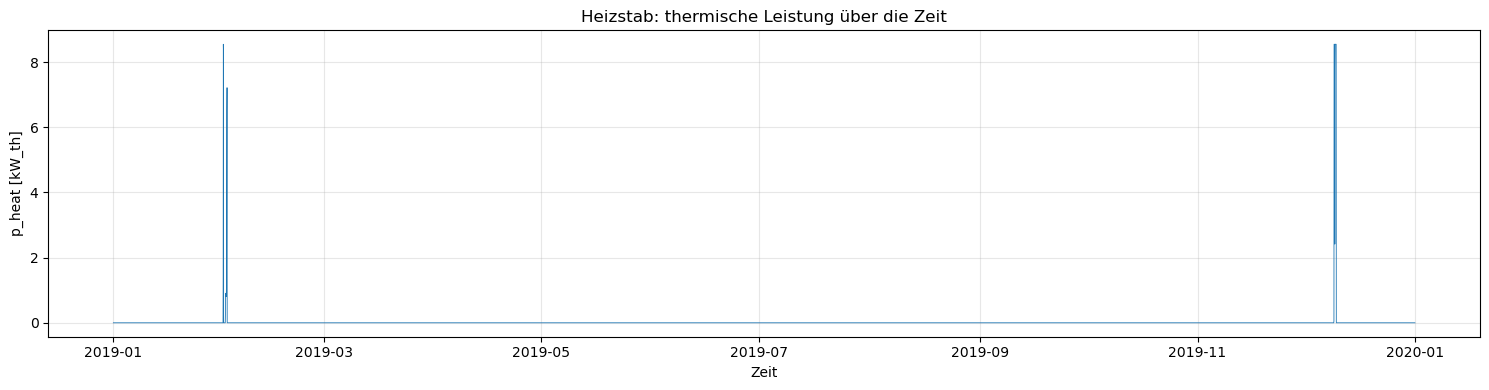

In [18]:
# ---------------------------------------
# Heizstab-Auswertung (backup_heater)
# ---------------------------------------

name = "backup_heater"

# verfügbare Keys anschauen
print("heating_elements_t keys:", list(n.heating_elements_t.keys()))

# helper: erste passende Zeitreihe nehmen
def get_ts(d, candidates):
    for c in candidates:
        if c in d:
            return d[c]
    raise KeyError(f"Keiner der Keys {candidates} in heating_elements_t vorhanden.")

# Kandidaten für "thermische Leistung" und "elektrische Leistung"
heat_key = get_ts(n.heating_elements_t, ["p_heat", "p1", "p_out", "p"])
elec_key = get_ts(n.heating_elements_t, ["p_elec", "p0", "p_in"])

# Das sind DataFrames → Spalte auswählen
p_heat = heat_key[name]
p_elec = elec_key[name]

print("\n--- Peaks ---")
print("max p_heat [kW]:", float(p_heat.max()))
print("max p_elec [kW]:", float(p_elec.max()))

# Plot
plt.figure(figsize=(15,4))
plt.plot(p_heat.index, p_heat.values, linewidth=0.6)
plt.title("Heizstab: thermische Leistung über die Zeit")
plt.xlabel("Zeit")
plt.ylabel("p_heat [kW_th]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Deckungsanteile Wärmeerzeuger (WP vs. Heizstab)

In [19]:
# ============================================================
# Deckungsanteile Wärmeerzeuger (WP vs. Heizstab)
# ============================================================

# Heizstab: Jahreswärme
Q_he = float(np.nansum(p_heat.values))   # kWh_th/a

# WP: Jahreswärme (hast du schon)
Q_wp = float(Q_hp)                       # kWh_th/a

Q_total = Q_wp + Q_he

wp_share = (Q_wp / Q_total) * 100 if Q_total > 0 else np.nan
he_share = (Q_he / Q_total) * 100 if Q_total > 0 else np.nan

print("\n====================================")
print("Deckungsanteile Wärmeerzeugung")
print("====================================")
print(f"Wärmepumpe: {wp_share:.2f} %")
print(f"Heizstab:   {he_share:.2f} %")
print(f"Gesamtwärme: {Q_total:.0f} kWh_th/a")



Deckungsanteile Wärmeerzeugung
Wärmepumpe: 99.78 %
Heizstab:   0.22 %
Gesamtwärme: 75414 kWh_th/a


#### Batterie – Auslegung & Betrieb



In [20]:
# Batteriedaten abfragen:

print("StorageUnits vorhanden:", getattr(n, "storage_units", pd.DataFrame()).index.tolist())

if "store_el" in getattr(n, "storage_units", pd.DataFrame()).index:
    print("\nstore_el Parameter:")
    print(n.storage_units.loc["store_el"])
    print("\nstore_el dispatch time series vorhanden?:",
          "store_el" in getattr(n, "storage_units_t", pd.DataFrame()).p.columns)
else:
    print("store_el ist nicht im Network gelandet.")

StorageUnits vorhanden: ['store_el']

store_el Parameter:
attribute
bus                                   electricity_grid
control                                             PQ
type                                                  
p_nom                                              0.0
p_nom_mod                                          0.0
p_nom_extendable                                 False
p_nom_min                                          0.0
p_nom_max                                          inf
p_min_pu                                          -1.0
p_max_pu                                           1.0
p_set                                              0.0
q_set                                              0.0
sign                                               1.0
carrier                                               
marginal_cost                                      0.0
marginal_cost_quadratic                            0.0
capital_cost                                 30.5783

#### Strombilanz


--- Strombilanz ---
Verbrauch gesamt (HH+WP+HE+BattLaden): 29933 kWh/a
Netzbezug:                             23313 kWh/a
PV-Erzeugung:                          15355 kWh/a
Einspeisung (Export):                  -8734 kWh/a
Batterie Laden:                        0 kWh/a
Batterie Entladen:                     0 kWh/a
Autarkiegrad:                          22.1 %


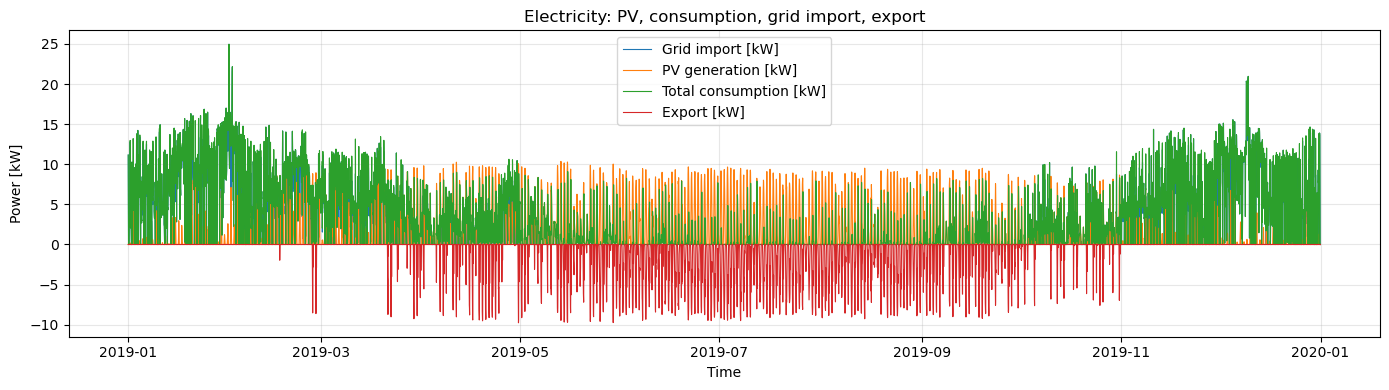

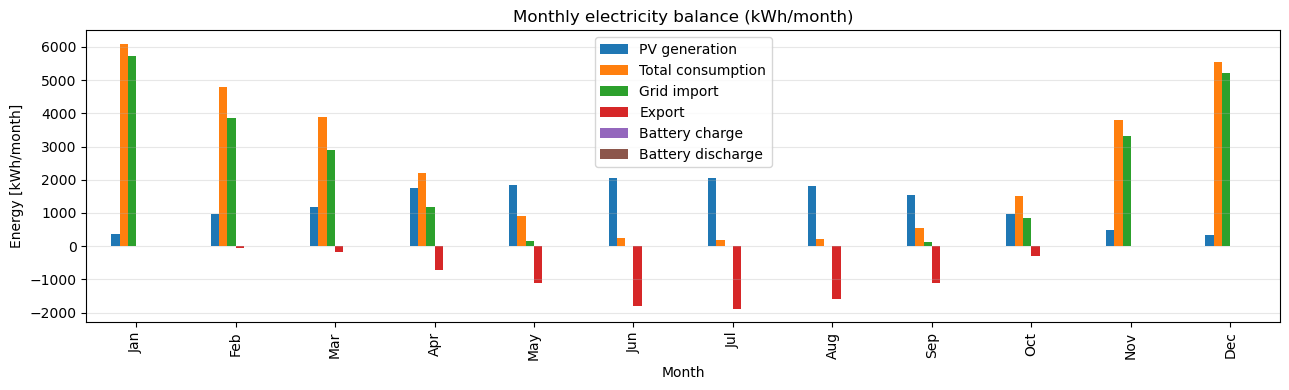

In [21]:
# ================================
#  ## - Netzbezug - PV Gen. - Einspeisung etc.
# ================================
time_index = n.snapshots

# --- 1) PV generation (kW) ---
pv_gen = n.generators_t.p["pv_generation"]  # kW, >=0

# --- 2) Grid import (kW) ---
grid_import = n.generators_t.p["grid_import"]  # kW, >=0

# --- 3) Feed-in / export (kW, make it positive) ---
if "pv_infeed" in n.generators_t.p.columns:
    export = -n.generators_t.p["pv_infeed"]     # kW, >=0
else:
    export = pd.Series(0.0, index=n.snapshots)

# --- 4) Household electric load (kW) ---
load_el = n.loads_t.p["el_demand"]  # kW

# --- 5) Heat pump electric consumption (kW) ---
hp_t = n.pnl("HeatPump")
hp_p_el = hp_t["p_elec"]["hp_mfh"]
hp_p_el_total = hp_p_el.sum(axis=1) if isinstance(hp_p_el, pd.DataFrame) else hp_p_el  # kW

# --- 6) Heating element electric consumption (kW) ---
he_t = n.pnl("HeatingElement")
he_p_el = he_t["p_elec"]["backup_heater"]
he_p_el_total = he_p_el.sum(axis=1) if isinstance(he_p_el, pd.DataFrame) else he_p_el  # kW

# --- 7) Battery (kW): StorageUnit p > 0 discharges to bus, p < 0 charges from bus ---
if "store_el" in getattr(n, "storage_units", pd.DataFrame()).index and \
   "store_el" in getattr(n, "storage_units_t", pd.DataFrame()).p.columns:
    bat_p = n.storage_units_t.p["store_el"]  # kW
    bat_charge = (-bat_p).clip(lower=0)      # kW charging
    bat_discharge = (bat_p).clip(lower=0)    # kW discharging
else:
    bat_charge = pd.Series(0.0, index=n.snapshots)
    bat_discharge = pd.Series(0.0, index=n.snapshots)

# --- Total electric consumption on the grid bus (kW) ---
# This is what must be covered by PV (via link), battery discharge, and grid import.
total_consumption = load_el + hp_p_el_total + he_p_el_total + bat_charge

# --- Energies (kWh) for hourly data: sum of kW values ---
E_grid = float(grid_import.sum())
E_cons = float(total_consumption.sum())
E_pv = float(pv_gen.sum())
E_exp = float(export.sum())
E_bat_chg = float(bat_charge.sum())
E_bat_dis = float(bat_discharge.sum())

autarkiegrad = 1 - (E_grid / E_cons) if E_cons > 0 else np.nan

print("\n--- Strombilanz ---")
print(f"Verbrauch gesamt (HH+WP+HE+BattLaden): {E_cons:.0f} kWh/a")
print(f"Netzbezug:                             {E_grid:.0f} kWh/a")
print(f"PV-Erzeugung:                          {E_pv:.0f} kWh/a")
print(f"Einspeisung (Export):                  {E_exp:.0f} kWh/a")
print(f"Batterie Laden:                        {E_bat_chg:.0f} kWh/a")
print(f"Batterie Entladen:                     {E_bat_dis:.0f} kWh/a")
print(f"Autarkiegrad:                          {autarkiegrad*100:.1f} %")

# --- Plot: power time series ---
plt.figure(figsize=(14,4))
plt.plot(time_index, grid_import.values, label="Grid import [kW]", linewidth=0.8)
plt.plot(time_index, pv_gen.values, label="PV generation [kW]", linewidth=0.8)
plt.plot(time_index, total_consumption.values, label="Total consumption [kW]", linewidth=0.8)
plt.plot(time_index, export.values, label="Export [kW]", linewidth=0.8)
plt.title("Electricity: PV, consumption, grid import, export")
plt.xlabel("Time")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Monthly energy bars (kWh/month) ---
pv_ts   = pd.Series(pv_gen.to_numpy(), index=time_index)
cons_ts = pd.Series(total_consumption.to_numpy(), index=time_index)
imp_ts  = pd.Series(grid_import.to_numpy(), index=time_index)
exp_ts  = pd.Series(export.to_numpy(), index=time_index)
chg_ts  = pd.Series(bat_charge.to_numpy(), index=time_index)
dis_ts  = pd.Series(bat_discharge.to_numpy(), index=time_index)

monthly = pd.DataFrame({
    "PV generation":     pv_ts.resample("ME").sum(),
    "Total consumption": cons_ts.resample("ME").sum(),
    "Grid import":       imp_ts.resample("ME").sum(),
    "Export":            exp_ts.resample("ME").sum(),
    "Battery charge":    chg_ts.resample("ME").sum(),
    "Battery discharge": dis_ts.resample("ME").sum(),
})
monthly.index = monthly.index.strftime("%b")

ax = monthly.plot(kind="bar", figsize=(13,4))
ax.set_title("Monthly electricity balance (kWh/month)")
ax.set_xlabel("Month")
ax.set_ylabel("Energy [kWh/month]")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#### Wärmegestehungskosten Berechnung

In [22]:
print("Objective (total system cost):", n.objective)
print("Capital expenditures (CAPEX):", n.statistics.capex())
print("Operational expenditures (OPEX):", n.statistics.opex())
grid_costs_total = grid_cost * E_grid
print("Gridcosts", grid_cost * E_grid)
costs_total = n.objective + grid_costs_total
print("Total costs", costs_total)

warmegesthehungskosten = costs_total / Q_hp     # Heizstab noch hinzu
print(f"Wärmegestehungskosten: {warmegesthehungskosten:.2f} €/kWh_th")


Objective (total system cost): 7992.800616065574
Capital expenditures (CAPEX): component  carrier
Generator  -          581.17229
dtype: float64
Operational expenditures (OPEX): component  carrier
Generator  -          7992.80062
dtype: float64
Gridcosts 8672.297776967811
Total costs 16665.098393033386
Wärmegestehungskosten: 0.22 €/kWh_th


### Ergebnisse Speichern

In [23]:
# ============================================================
# Ergebnis-CSV
# ============================================================

scenario_id = f"{lastgang_version}__Tv{int(T_vorlauf)}__{'HK' if use_radiators else 'FBH'}"
# z.B. "ist_zst__Tv55__HK"

results_row = {
    "scenario_id": scenario_id,
    "lastgang_version": lastgang_version,
    "lastgang_file": lastgang_file,
    "use_radiators": use_radiators,
    "T_vorlauf_C": float(T_vorlauf),
    "JAZ_wp": float(JAZ_hp),
    "WP_Nennleistung": float(HP_power),
    "WP_Deckungsanteil": float(wp_share),
    "HE_Nennleistung": float(HE_power),
    "HE_Deckungsanteil": float(he_share),
    "waermegestehungskosten_EUR_per_kWh_th": float(warmegesthehungskosten),
    "Total_costs_€/a": float(n.objective),
    "CAPEX_€/a": float(n.statistics.capex()),
    "OPEX_€/a": float(n.statistics.opex()),
    "grid_import_kWh": float(E_grid),
    "Q_hp_kWh_th": float(Q_hp),
    "E_hp_kWh_el": float(E_hp),
}

BASE_DIR = Path.cwd()

results_dir = BASE_DIR / "Output" / "sensitivity_runs"
results_dir.mkdir(parents=True, exist_ok=True)

results_path = results_dir / f"results_{scenario_id}.csv"

df_out = pd.DataFrame([results_row])
df_out.to_csv(results_path, index=False)

print(f"\n Neue Datei pro Run gespeichert in:\n{results_path.resolve()}")



 Neue Datei pro Run gespeichert in:
C:\Users\sarah\Documents\GitHub\EMM_Projekt_Gruppe4\Finaler_Code_Varianten\Output\sensitivity_runs\results_Ist_ZST__Tv51__HK.csv


C:\Users\sarah\AppData\Local\Temp\ipykernel_42552\711453414.py:21: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

C:\Users\sarah\AppData\Local\Temp\ipykernel_42552\711453414.py:22: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

